Hospital Dataset
     Department Month  Admissions
0    Cardiology   Jan         120
1     Neurology   Jan          95
2    Pediatrics   Jan         150
3   Orthopedics   Jan         110
4     Emergency   Jan         200
5    Cardiology   Feb         130
6     Neurology   Feb         100
7    Pediatrics   Feb         160
8   Orthopedics   Feb         115
9     Emergency   Feb         220
10   Cardiology   Mar         125
11    Neurology   Mar          98
12   Pediatrics   Mar         155
13  Orthopedics   Mar         120
14    Emergency   Mar         210


/tmp/ipykernel_1028/2138792939.py:42: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Department", y="Admissions", estimator=sum, ci=None, palette="Set2")
/tmp/ipykernel_1028/2138792939.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Department", y="Admissions", estimator=sum, ci=None, palette="Set2")


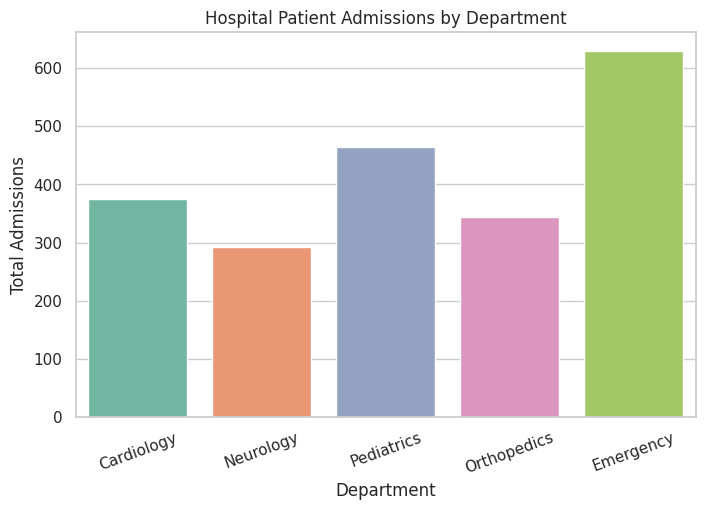

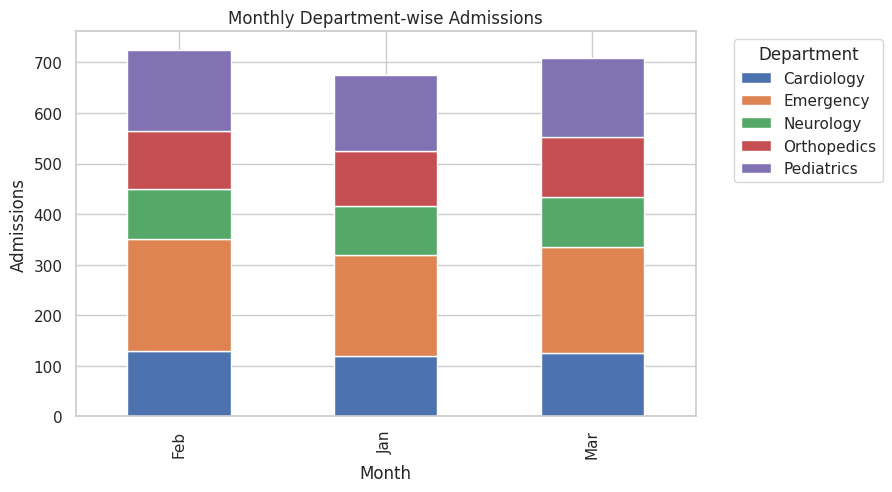

/tmp/ipykernel_1028/2138792939.py:82: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




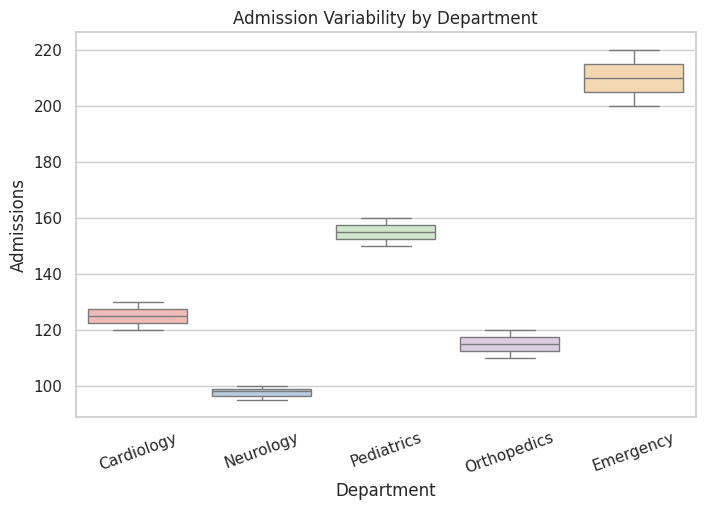

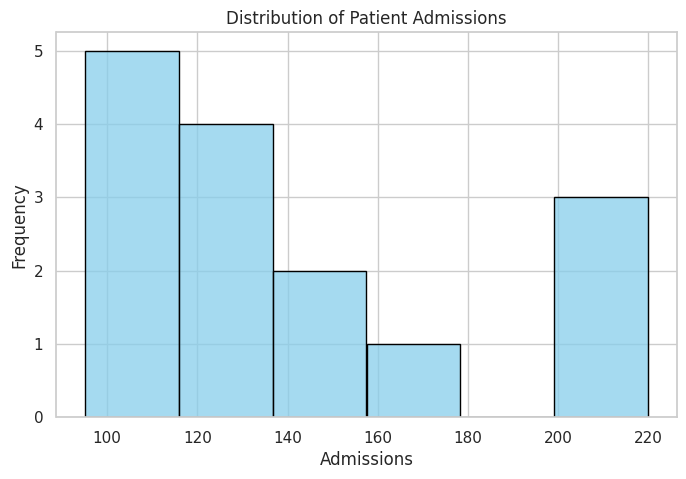


INSIGHTS
1. Emergency department has the highest patient admissions.
2. Pediatrics is the second busiest department.
3. Neurology has the lowest admissions.
4. Box plot shows admission variability across departments.
5. Histogram shows most admission values are between 100 and 200.


In [1]:
# ================================
# Hospital Patient Admission Analysis
# ================================
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# Create Dataset
data = {
    "Department": [
        "Cardiology","Neurology","Pediatrics","Orthopedics","Emergency",
        "Cardiology","Neurology","Pediatrics","Orthopedics","Emergency",
        "Cardiology","Neurology","Pediatrics","Orthopedics","Emergency"
    ],
    "Month": [
        "Jan","Jan","Jan","Jan","Jan",
        "Feb","Feb","Feb","Feb","Feb",
        "Mar","Mar","Mar","Mar","Mar"
    ],
    "Admissions": [
        120,95,150,110,200,
        130,100,160,115,220,
        125,98,155,120,210
    ]
}
df = pd.DataFrame(data)
print("Hospital Dataset")
print(df)
# Set style
sns.set(style="whitegrid")
# ======================================
# 1. Bar Chart
# ======================================
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Department", y="Admissions", estimator=sum, ci=None, palette="Set2")
plt.title("Hospital Patient Admissions by Department")
plt.xlabel("Department")
plt.ylabel("Total Admissions")
plt.xticks(rotation=20)
plt.show()-ovxxxxxxxx
# ======================================
# 2. Stacked Bar Chart
# ======================================
pivot = df.pivot_table(index="Month",
                       columns="Department",
                       values="Admissions",
                       aggfunc="sum")

pivot.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Monthly Department-wise Admissions")
plt.xlabel("Month")
plt.ylabel("Admissions")
plt.legend(title="Department", bbox_to_anchor=(1.05,1))
plt.show()

# ======================================
# 3. Treemap (Plotly)
# ======================================
dept_total = df.groupby("Department")["Admissions"].sum().reset_index()

fig = px.treemap(
    dept_total,
    path=["Department"],
    values="Admissions",
    title="Treemap of Hospital Admissions"
)

fig.show()

# ======================================
# 4. Box Plot
# ======================================
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Department", y="Admissions", palette="Pastel1")
plt.title("Admission Variability by Department")
plt.xlabel("Department")
plt.ylabel("Admissions")
plt.xticks(rotation=20)
plt.show()

# ======================================
# 5. Histogram
# ======================================
plt.figure(figsize=(8,5))
sns.histplot(df["Admissions"], bins=6, color="skyblue", edgecolor="black")
plt.title("Distribution of Patient Admissions")
plt.xlabel("Admissions")
plt.ylabel("Frequency")
plt.show()

# ======================================
# Insights
# ======================================
print("\nINSIGHTS")
print("1. Emergency department has the highest patient admissions.")
print("2. Pediatrics is the second busiest department.")
print("3. Neurology has the lowest admissions.")
print("4. Box plot shows admission variability across departments.")
print("5. Histogram shows most admission values are between 100 and 200.")

E-Commerce Customer Spending Dataset
  Customer  Purchase_Amount  Order_Frequency Product_Category
0       C1             1200                5      Electronics
1       C2             3500               12         Clothing
2       C3             1800                6        Groceries
3       C4             4500               15      Electronics
4       C5             2200                8             Home
5       C6             5100               18      Electronics
6       C7             3900               13         Clothing
7       C8             2700                9             Home
8       C9             6200               20      Electronics
9      C10             4100               14        Groceries


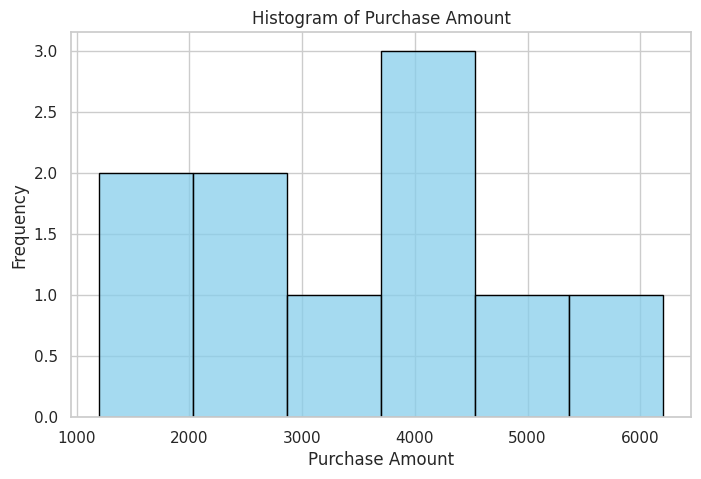

/tmp/ipykernel_1028/1892639672.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




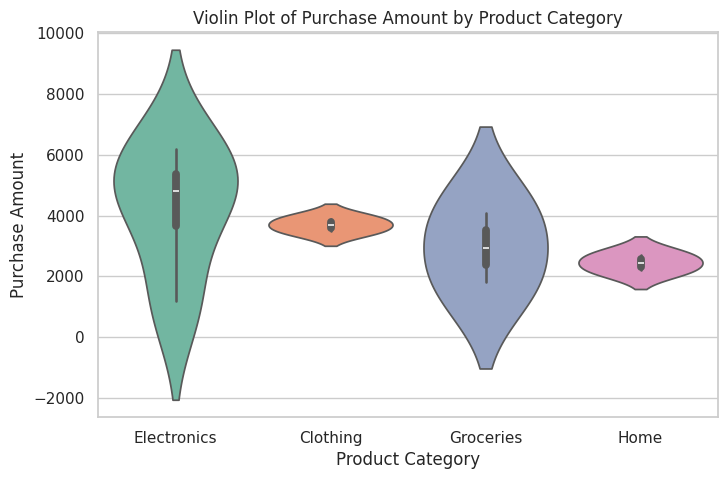

/tmp/ipykernel_1028/1892639672.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




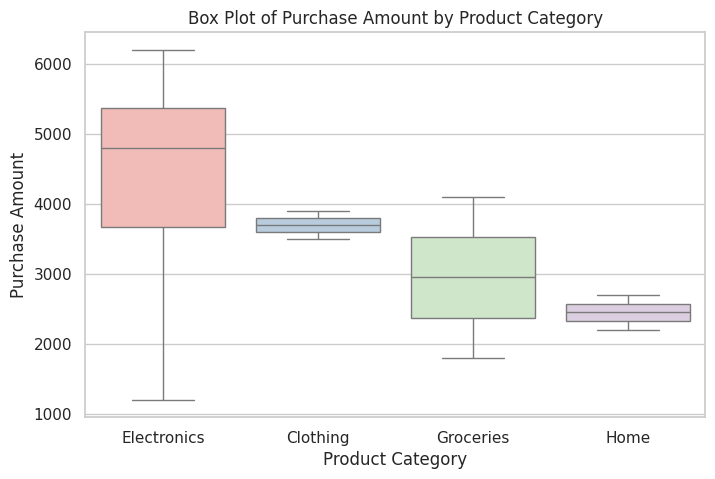

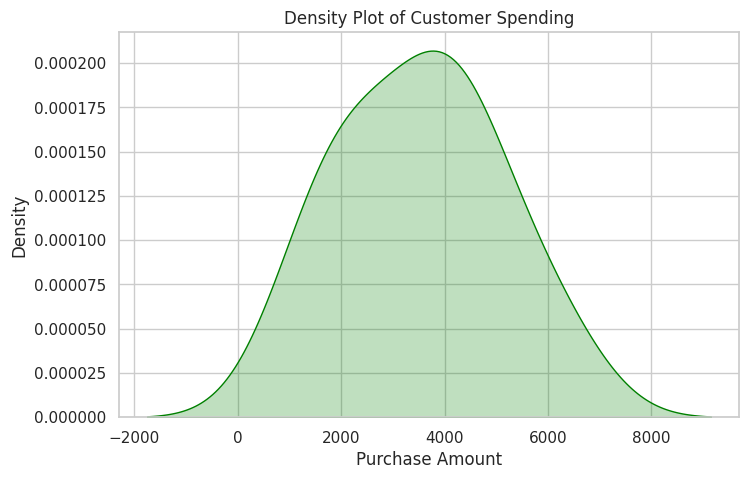

/tmp/ipykernel_1028/1892639672.py:75: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




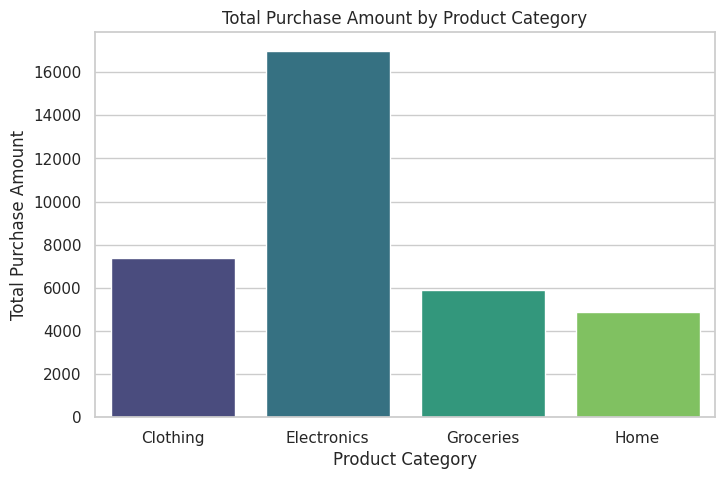


===== INSIGHTS =====
1. High-value customers spend above ₹5000.
2. Electronics category generates the highest total revenue.
3. Box plot identifies spending variability and possible outliers.
4. Violin plot shows the distribution and concentration of customer spending.
5. Density plot highlights the overall spending pattern.
6. Bar chart clearly compares sales across product categories.

===== RECOMMENDATION =====
• High-value Customers      : Box Plot
• Spending Variability      : Violin Plot
• Purchasing Trends         : Bar Chart
• Best for Business Executives : Bar Chart
Reason: It is simple, easy to understand, and clearly compares revenue across product categories.


In [2]:
# ============================================
# E-Commerce Customer Spending Behaviour
# ============================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Create Dataset
data = {
    "Customer": ["C1","C2","C3","C4","C5","C6","C7","C8","C9","C10"],
    "Purchase_Amount": [1200, 3500, 1800, 4500, 2200, 5100, 3900, 2700, 6200, 4100],
    "Order_Frequency": [5, 12, 6, 15, 8, 18, 13, 9, 20, 14],
    "Product_Category": ["Electronics","Clothing","Groceries","Electronics",
                         "Home","Electronics","Clothing","Home",
                         "Electronics","Groceries"]
}

df = pd.DataFrame(data)

print("E-Commerce Customer Spending Dataset")
print(df)

# Set Theme
sns.set(style="whitegrid")

# ============================================
# 1. Histogram
# ============================================
plt.figure(figsize=(8,5))
sns.histplot(df["Purchase_Amount"], bins=6, color="skyblue", edgecolor="black")
plt.title("Histogram of Purchase Amount")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

# ============================================
# 2. Violin Plot
# ============================================
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="Product_Category", y="Purchase_Amount", palette="Set2")
plt.title("Violin Plot of Purchase Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Purchase Amount")
plt.show()

# ============================================
# 3. Box Plot
# ============================================
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Product_Category", y="Purchase_Amount", palette="Pastel1")
plt.title("Box Plot of Purchase Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Purchase Amount")
plt.show()

# ============================================
# 4. Density Plot
# ============================================
plt.figure(figsize=(8,5))
sns.kdeplot(df["Purchase_Amount"], fill=True, color="green")
plt.title("Density Plot of Customer Spending")
plt.xlabel("Purchase Amount")
plt.ylabel("Density")
plt.show()

# ============================================
# 5. Bar Chart
# ============================================
category_sales = df.groupby("Product_Category")["Purchase_Amount"].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=category_sales,
            x="Product_Category",
            y="Purchase_Amount",
            palette="viridis")
plt.title("Total Purchase Amount by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Purchase Amount")
plt.show()

# ============================================
# Interactive Bar Chart (Plotly Express)
# ============================================
fig = px.bar(
    category_sales,
    x="Product_Category",
    y="Purchase_Amount",
    color="Product_Category",
    title="Interactive Total Spending by Product Category"
)
fig.show()

# ============================================
# Insights
# ============================================
print("\n===== INSIGHTS =====")
print("1. High-value customers spend above ₹5000.")
print("2. Electronics category generates the highest total revenue.")
print("3. Box plot identifies spending variability and possible outliers.")
print("4. Violin plot shows the distribution and concentration of customer spending.")
print("5. Density plot highlights the overall spending pattern.")
print("6. Bar chart clearly compares sales across product categories.")

print("\n===== RECOMMENDATION =====")
print("• High-value Customers      : Box Plot")
print("• Spending Variability      : Violin Plot")
print("• Purchasing Trends         : Bar Chart")
print("• Best for Business Executives : Bar Chart")
print("Reason: It is simple, easy to understand, and clearly compares revenue across product categories.")

University Examination Dataset
   Department Class  Marks
0         CSE     A     85
1         CSE     B     92
2         CSE     C     76
3         ECE     A     88
4         ECE     B     79
5         ECE     C     95
6        MECH     A     68
7        MECH     B     74
8        MECH     C     82
9       AI&DS     A     91
10      AI&DS     B     87
11      AI&DS     C     96


/tmp/ipykernel_1028/646100194.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




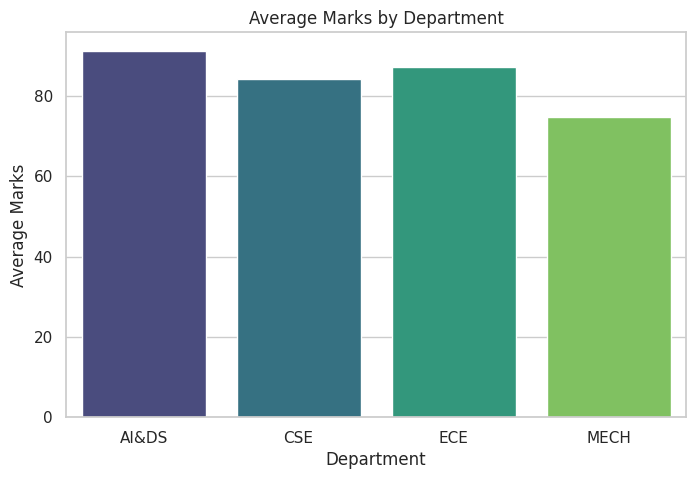

/tmp/ipykernel_1028/646100194.py:47: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




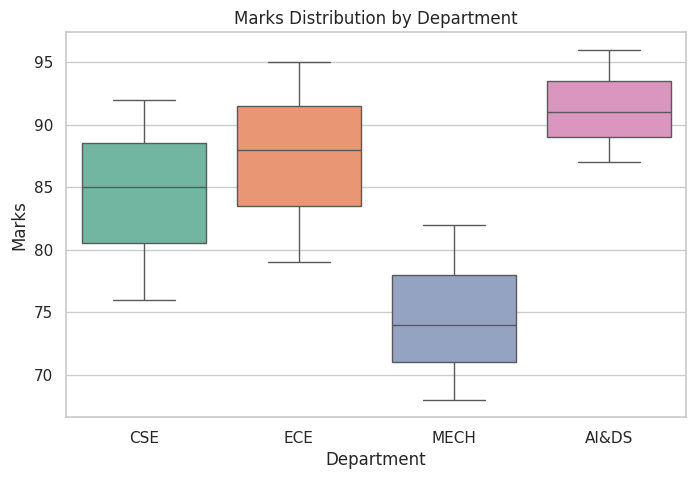

/tmp/ipykernel_1028/646100194.py:60: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




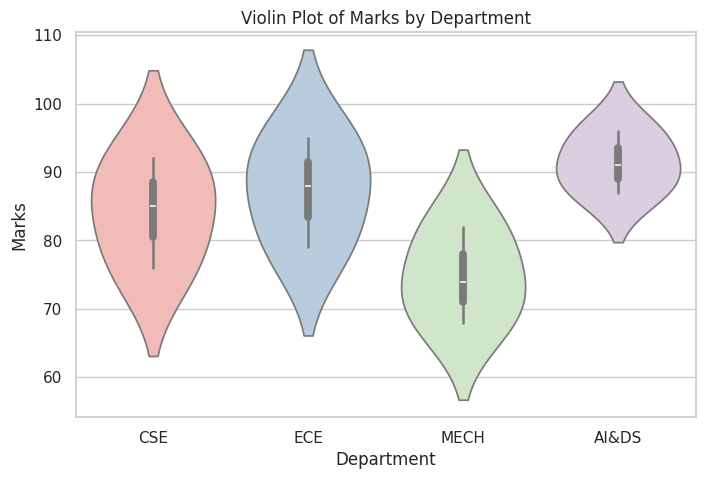

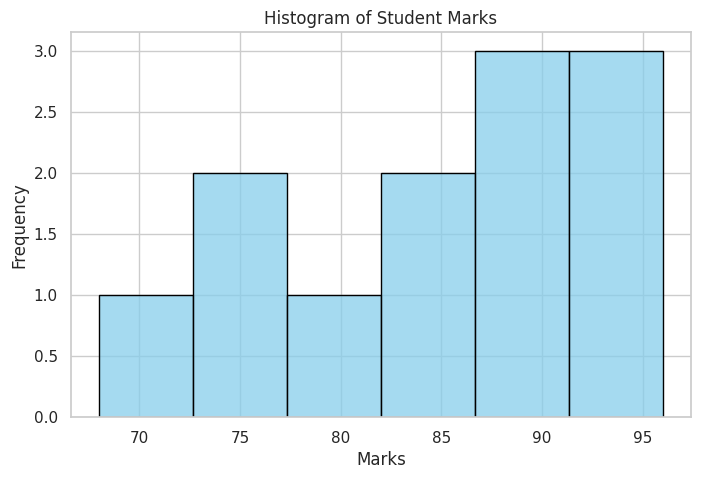

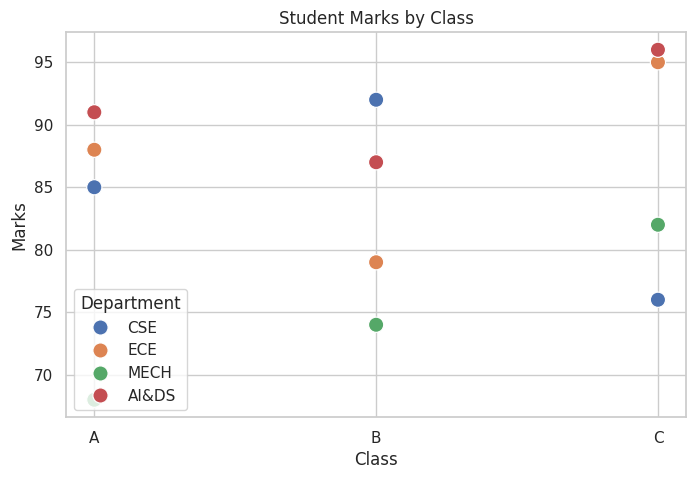


Top Performing Classes
   Department Class  Marks
11      AI&DS     C     96
5         ECE     C     95
1         CSE     B     92
9       AI&DS     A     91
3         ECE     A     88
10      AI&DS     B     87
0         CSE     A     85
8        MECH     C     82
4         ECE     B     79
2         CSE     C     76
7        MECH     B     74
6        MECH     A     68

===== INSIGHTS =====
1. AI&DS has the highest average marks.
2. Mechanical department has comparatively lower scores.
3. Box plot helps identify score variability and outliers.
4. Histogram shows the overall distribution of marks.
5. Scatter plot compares class-wise performance across departments.

===== RECOMMENDATION =====
• Department Comparison : Bar Chart
• Score Distribution    : Histogram
• Outlier Detection     : Box Plot
• Class Performance     : Scatter Plot
• Best Dashboard        : Combine Bar Chart + Box Plot + Histogram + Interactive Plotly Chart

===== DASHBOARD IMPROVEMENTS =====
1. Add department fil

In [3]:
# ============================================
# University Examination Performance Dashboard
# ============================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Create Dataset
data = {
    "Department": ["CSE","CSE","CSE","ECE","ECE","ECE",
                   "MECH","MECH","MECH","AI&DS","AI&DS","AI&DS"],
    "Class": ["A","B","C","A","B","C",
              "A","B","C","A","B","C"],
    "Marks": [85,92,76,88,79,95,68,74,82,91,87,96]
}

df = pd.DataFrame(data)

print("University Examination Dataset")
print(df)

# Set Theme
sns.set(style="whitegrid")

# ============================================
# 1. Bar Chart - Average Marks by Department
# ============================================
dept_avg = df.groupby("Department")["Marks"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=dept_avg,
            x="Department",
            y="Marks",
            palette="viridis")
plt.title("Average Marks by Department")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()

# ============================================
# 2. Box Plot - Score Distribution
# ============================================
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x="Department",
            y="Marks",
            palette="Set2")
plt.title("Marks Distribution by Department")
plt.xlabel("Department")
plt.ylabel("Marks")
plt.show()

# ============================================
# 3. Violin Plot - Distribution of Marks
# ============================================
plt.figure(figsize=(8,5))
sns.violinplot(data=df,
               x="Department",
               y="Marks",
               palette="Pastel1")
plt.title("Violin Plot of Marks by Department")
plt.xlabel("Department")
plt.ylabel("Marks")
plt.show()

# ============================================
# 4. Histogram - Overall Marks Distribution
# ============================================
plt.figure(figsize=(8,5))
sns.histplot(df["Marks"],
             bins=6,
             color="skyblue",
             edgecolor="black")
plt.title("Histogram of Student Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

# ============================================
# 5. Scatter Plot - Class vs Marks
# ============================================
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="Class",
                y="Marks",
                hue="Department",
                s=120)
plt.title("Student Marks by Class")
plt.xlabel("Class")
plt.ylabel("Marks")
plt.show()

# ============================================
# Interactive Plotly Bar Chart
# ============================================
fig = px.bar(
    dept_avg,
    x="Department",
    y="Marks",
    color="Department",
    title="Interactive Average Marks by Department"
)

fig.show()

# ============================================
# Top Performing Classes
# ============================================
top_classes = df.sort_values(by="Marks", ascending=False)

print("\nTop Performing Classes")
print(top_classes[["Department","Class","Marks"]])

# ============================================
# Insights
# ============================================
print("\n===== INSIGHTS =====")
print("1. AI&DS has the highest average marks.")
print("2. Mechanical department has comparatively lower scores.")
print("3. Box plot helps identify score variability and outliers.")
print("4. Histogram shows the overall distribution of marks.")
print("5. Scatter plot compares class-wise performance across departments.")

print("\n===== RECOMMENDATION =====")
print("• Department Comparison : Bar Chart")
print("• Score Distribution    : Histogram")
print("• Outlier Detection     : Box Plot")
print("• Class Performance     : Scatter Plot")
print("• Best Dashboard        : Combine Bar Chart + Box Plot + Histogram + Interactive Plotly Chart")

print("\n===== DASHBOARD IMPROVEMENTS =====")
print("1. Add department filter.")
print("2. Include semester-wise comparison.")
print("3. Display pass percentage and toppers.")
print("4. Add average, median, and highest marks.")
print("5. Use interactive Plotly charts for better academic decision-making.")

Climate and Rainfall Dataset
         City Month  Rainfall  Temperature  Humidity
0     Chennai   Jan        25           29        68
1      Mumbai   Jan       120           31        85
2       Delhi   Jan        15           25        45
3   Bangalore   Jan        80           27        70
4     Chennai   Jun        60           35        75
5      Mumbai   Jun       350           30        90
6       Delhi   Jun        90           40        40
7   Bangalore   Jun       150           28        80
8     Chennai   Oct       280           30        88
9      Mumbai   Oct       200           29        86
10      Delhi   Oct        35           27        50
11  Bangalore   Oct       180           26        82


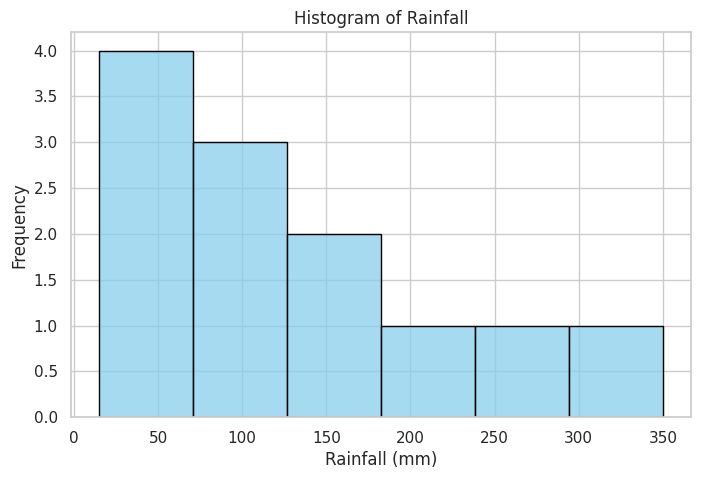

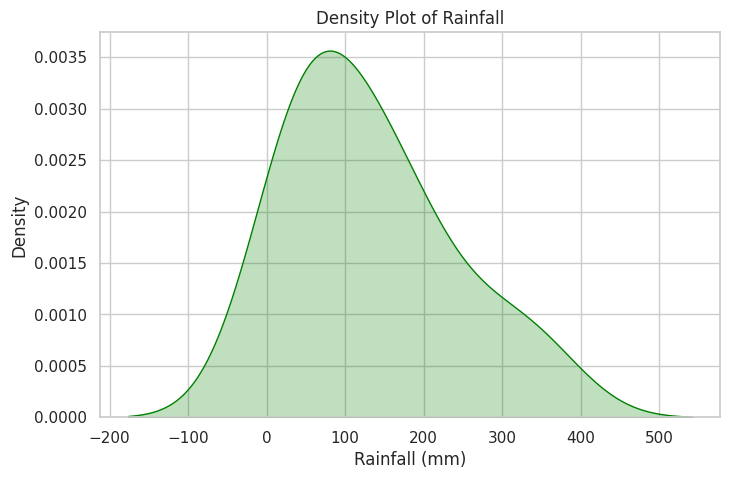

/tmp/ipykernel_1028/518486718.py:64: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




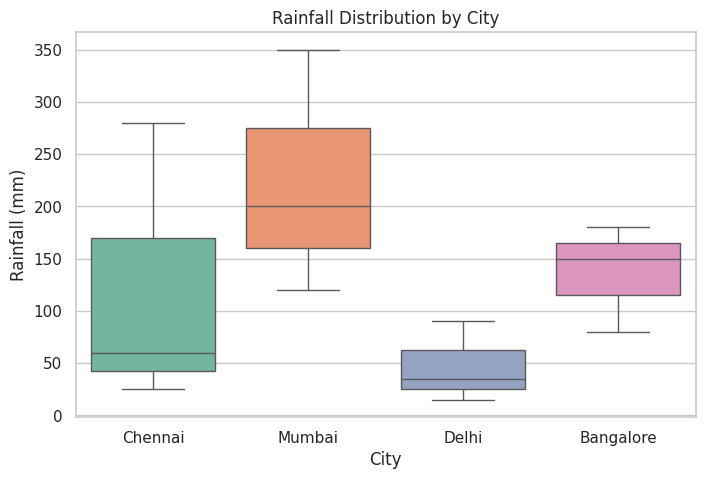

/tmp/ipykernel_1028/518486718.py:79: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




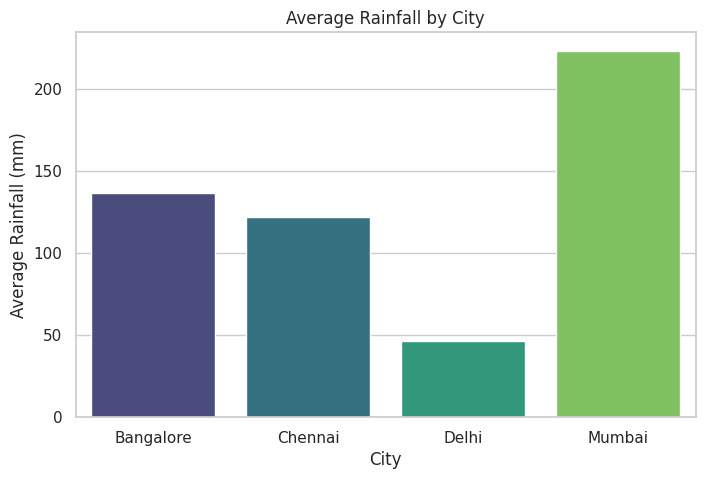


===== INSIGHTS =====
1. Mumbai receives the highest average rainfall.
2. Delhi has the lowest rainfall among the cities.
3. Box plot clearly shows rainfall variation across cities.
4. Histogram displays the overall rainfall frequency distribution.
5. Density plot shows rainfall concentration and spread.
6. Bar chart compares average rainfall between cities.

===== COMPARISON OF VISUALIZATIONS =====
Histogram  : Shows rainfall frequency distribution.
Density Plot : Displays the smooth rainfall distribution pattern.
Box Plot : Best for seasonal variation and identifying outliers.
Bar Chart : Best for comparing average rainfall across cities.

===== RECOMMENDATION =====
Best Visualization for Seasonal Rainfall Variation : Box Plot
Reason : It clearly represents rainfall variability, median values, and outliers.

Best Visualization for Climate Distribution : Density Plot
Reason : It shows how rainfall values are distributed across the dataset.

Most Suitable for Environmental Researchers 

In [4]:
# ============================================
# Climate and Rainfall Distribution Study
# ============================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create Dataset
data = {
    "City": [
        "Chennai","Mumbai","Delhi","Bangalore",
        "Chennai","Mumbai","Delhi","Bangalore",
        "Chennai","Mumbai","Delhi","Bangalore"
    ],
    "Month": [
        "Jan","Jan","Jan","Jan",
        "Jun","Jun","Jun","Jun",
        "Oct","Oct","Oct","Oct"
    ],
    "Rainfall": [25,120,15,80,60,350,90,150,280,200,35,180],
    "Temperature": [29,31,25,27,35,30,40,28,30,29,27,26],
    "Humidity": [68,85,45,70,75,90,40,80,88,86,50,82]
}

df = pd.DataFrame(data)

print("Climate and Rainfall Dataset")
print(df)

# Set Theme
sns.set(style="whitegrid")

# ============================================
# 1. Histogram - Rainfall Distribution
# ============================================
plt.figure(figsize=(8,5))
sns.histplot(df["Rainfall"],
             bins=6,
             color="skyblue",
             edgecolor="black")
plt.title("Histogram of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.show()

# ============================================
# 2. Density Plot - Rainfall Distribution
# ============================================
plt.figure(figsize=(8,5))
sns.kdeplot(df["Rainfall"],
            fill=True,
            color="green")
plt.title("Density Plot of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Density")
plt.show()

# ============================================
# 3. Box Plot - Rainfall by City
# ============================================
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x="City",
            y="Rainfall",
            palette="Set2")
plt.title("Rainfall Distribution by City")
plt.xlabel("City")
plt.ylabel("Rainfall (mm)")
plt.show()

# ============================================
# 4. Bar Chart - Average Rainfall by City
# ============================================
avg_rainfall = df.groupby("City")["Rainfall"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=avg_rainfall,
            x="City",
            y="Rainfall",
            palette="viridis")
plt.title("Average Rainfall by City")
plt.xlabel("City")
plt.ylabel("Average Rainfall (mm)")
plt.show()

# ============================================
# Insights
# ============================================
print("\n===== INSIGHTS =====")
print("1. Mumbai receives the highest average rainfall.")
print("2. Delhi has the lowest rainfall among the cities.")
print("3. Box plot clearly shows rainfall variation across cities.")
print("4. Histogram displays the overall rainfall frequency distribution.")
print("5. Density plot shows rainfall concentration and spread.")
print("6. Bar chart compares average rainfall between cities.")

print("\n===== COMPARISON OF VISUALIZATIONS =====")
print("Histogram  : Shows rainfall frequency distribution.")
print("Density Plot : Displays the smooth rainfall distribution pattern.")
print("Box Plot : Best for seasonal variation and identifying outliers.")
print("Bar Chart : Best for comparing average rainfall across cities.")

print("\n===== RECOMMENDATION =====")
print("Best Visualization for Seasonal Rainfall Variation : Box Plot")
print("Reason : It clearly represents rainfall variability, median values, and outliers.")

print("\nBest Visualization for Climate Distribution : Density Plot")
print("Reason : It shows how rainfall values are distributed across the dataset.")

print("\nMost Suitable for Environmental Researchers : Combination of Box Plot + Density Plot + Bar Chart")
print("Reason : These charts together provide rainfall variation, climate distribution, and city-wise comparison.")

Bank Loan Risk Assessment Dataset
  Customer  Loan_Amount  Income  Credit_Score Repayment_History
0       C1       200000   40000           720              Good
1       C2       500000   80000           650           Average
2       C3       150000   35000           780              Good
3       C4       800000  120000           600              Poor
4       C5       300000   50000           710              Good
5       C6      1000000  150000           580              Poor
6       C7       250000   45000           760              Good
7       C8       450000   70000           690           Average
8       C9       700000  110000           620              Poor
9      C10       600000   90000           680           Average


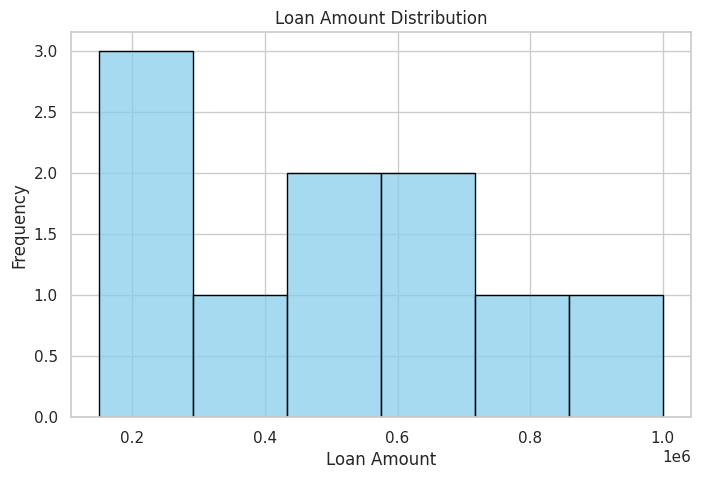

/tmp/ipykernel_1028/206799739.py:46: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




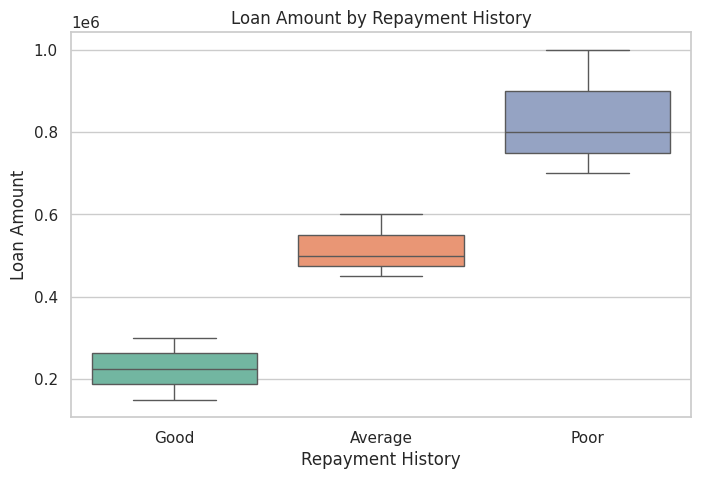

/tmp/ipykernel_1028/206799739.py:59: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




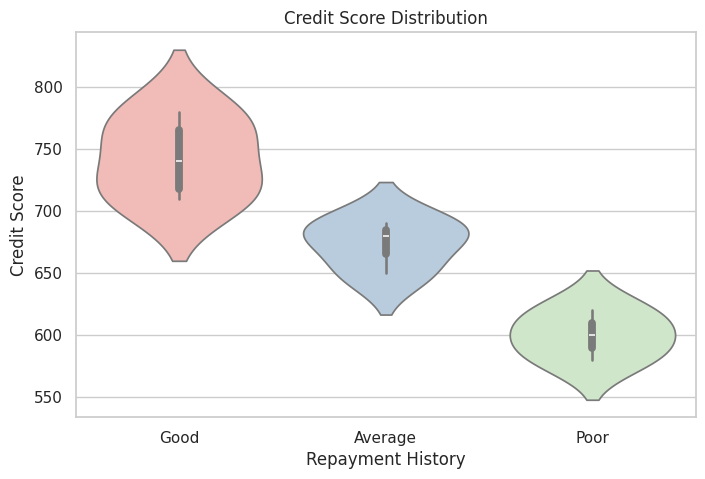

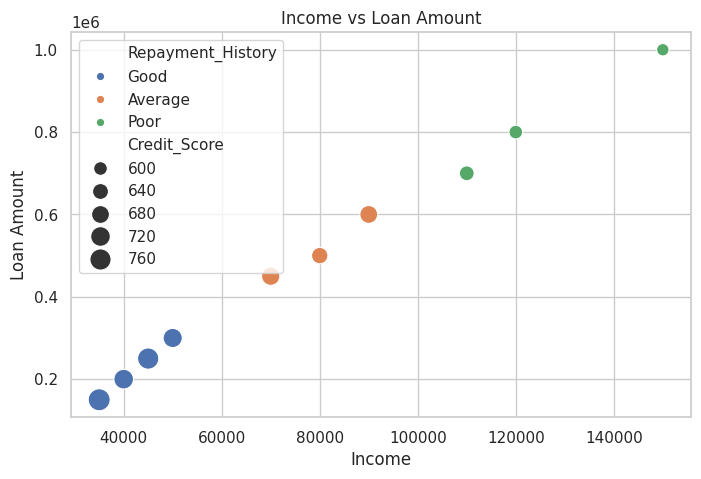

/tmp/ipykernel_1028/206799739.py:89: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




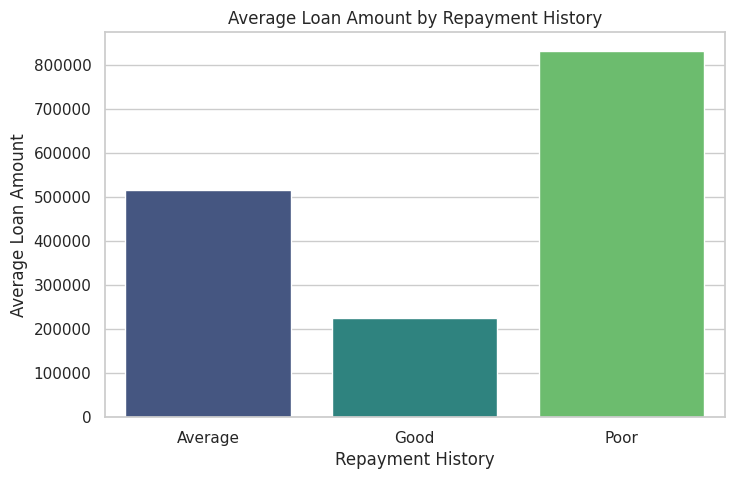


===== INSIGHTS =====
1. Customers with Poor repayment history generally have larger loan amounts.
2. Good repayment history is associated with higher credit scores.
3. Histogram shows the distribution of loan amounts.
4. Box plot identifies outliers and repayment-based risk.
5. Scatter plot highlights customer risk segments using income, loan amount, and credit score.
6. Bar chart compares average loan amounts by repayment history.

===== RECOMMENDATION =====
Best for Loan Distribution : Histogram
Best for Outliers & Risk Patterns : Box Plot
Best for Customer Segmentation : Scatter Plot
Best for Management Dashboard : Interactive Scatter Plot + Box Plot + Bar Chart
Reason: These charts clearly show customer segments, loan risk, outliers, and repayment trends for better loan approval decisions.


In [5]:
# ============================================
# Bank Loan Risk Assessment
# ============================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Create Dataset
data = {
    "Customer": ["C1","C2","C3","C4","C5","C6","C7","C8","C9","C10"],
    "Loan_Amount": [200000,500000,150000,800000,300000,1000000,250000,450000,700000,600000],
    "Income": [40000,80000,35000,120000,50000,150000,45000,70000,110000,90000],
    "Credit_Score": [720,650,780,600,710,580,760,690,620,680],
    "Repayment_History": ["Good","Average","Good","Poor","Good",
                          "Poor","Good","Average","Poor","Average"]
}

df = pd.DataFrame(data)

print("Bank Loan Risk Assessment Dataset")
print(df)

# Set Theme
sns.set(style="whitegrid")

# ============================================
# 1. Histogram - Loan Amount Distribution
# ============================================
plt.figure(figsize=(8,5))
sns.histplot(df["Loan_Amount"],
             bins=6,
             color="skyblue",
             edgecolor="black")
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

# ============================================
# 2. Box Plot - Loan Amount by Repayment History
# ============================================
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x="Repayment_History",
            y="Loan_Amount",
            palette="Set2")
plt.title("Loan Amount by Repayment History")
plt.xlabel("Repayment History")
plt.ylabel("Loan Amount")
plt.show()

# ============================================
# 3. Violin Plot - Credit Score Distribution
# ============================================
plt.figure(figsize=(8,5))
sns.violinplot(data=df,
               x="Repayment_History",
               y="Credit_Score",
               palette="Pastel1")
plt.title("Credit Score Distribution")
plt.xlabel("Repayment History")
plt.ylabel("Credit Score")
plt.show()

# ============================================
# 4. Scatter Plot - Income vs Loan Amount
# ============================================
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="Income",
                y="Loan_Amount",
                hue="Repayment_History",
                size="Credit_Score",
                sizes=(80,250))
plt.title("Income vs Loan Amount")
plt.xlabel("Income")
plt.ylabel("Loan Amount")
plt.show()

# ============================================
# 5. Bar Chart - Average Loan Amount
# ============================================
loan_avg = df.groupby("Repayment_History")["Loan_Amount"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=loan_avg,
            x="Repayment_History",
            y="Loan_Amount",
            palette="viridis")
plt.title("Average Loan Amount by Repayment History")
plt.xlabel("Repayment History")
plt.ylabel("Average Loan Amount")
plt.show()

# ============================================
# Interactive Plotly Scatter Plot
# ============================================
fig = px.scatter(
    df,
    x="Income",
    y="Loan_Amount",
    color="Repayment_History",
    size="Credit_Score",
    hover_name="Customer",
    title="Interactive Loan Risk Assessment"
)

fig.show()

# ============================================
# Insights
# ============================================
print("\n===== INSIGHTS =====")
print("1. Customers with Poor repayment history generally have larger loan amounts.")
print("2. Good repayment history is associated with higher credit scores.")
print("3. Histogram shows the distribution of loan amounts.")
print("4. Box plot identifies outliers and repayment-based risk.")
print("5. Scatter plot highlights customer risk segments using income, loan amount, and credit score.")
print("6. Bar chart compares average loan amounts by repayment history.")

print("\n===== RECOMMENDATION =====")
print("Best for Loan Distribution : Histogram")
print("Best for Outliers & Risk Patterns : Box Plot")
print("Best for Customer Segmentation : Scatter Plot")
print("Best for Management Dashboard : Interactive Scatter Plot + Box Plot + Bar Chart")
print("Reason: These charts clearly show customer segments, loan risk, outliers, and repayment trends for better loan approval decisions.")